# Shape Searching in Synthon Spaces

**Note** this is a guest post written by Dave Cosgrove (GitHub: @DavidACosgrove).

Substructure and fingerprint similarity searching in synthon spaces was introduced in the RDKit in [December 2024](https://greglandrum.github.io/rdkit-blog/posts/2024-12-03-introducing-synthon-search.html).  The motivation behind this method of searching synthon-based libraries such as ChemSpaces's [FreedomSpace](https://chem-space.com/freedom-space) or Enamine's [REAL](https://enamine.net/compound-collections/real-compounds/real-database) is that enumerating the individual compounds for search is infeasible - the libraries expand to tens of billions of compounds which cannot be stored and searched with current hardware.

Similarity search has now been extended to include 3D shapes, where the problems of searching are even more pronounced since the similarity measure (in this case using the RDKit's new rdGaussianShape module) is significantly slower and it is normally necessary to use multiple conformations of the synthons and any potential hits.

## Algorithm Overview

The algorithm is the same as that used for fingerprint similarity, but with a different similarity measure.

Briefly:

A database is prepared of synthon shapes, which only needs to be done once.  

![Create Synthon Shapes](images//blog/2026-09-10-create_synthon_db.png)

The query molecule is split into fragments and shapes created for them:

![Create Fragment Shapes](images//blog/2026-09-10-create_fragment_shapes.png)

The fragments are compared to the synthons and lists of the matches created:

![Compare Fragments to Synthons](images//blog/2026-09-10-compare.png)

For those fragment sets that have matching synthons, build the product and compare with the query.  If it matches according to the appropriate acceptance, it's a hit:

![Check Product Against Query](images//blog/2026-09-10-check.png)

For shape similarity searching, each synthon is represented by an `rdGaussianShape.ShapeInput` object containing 1 or more conformations and the final similarity check involves a conformational expansion of the possible hit and shape similarity calculation.

The algorithm is very similar to that of [Cheng and Beroza](https://pubs.acs.org/doi/10.1021/acs.jcim.3c01865#) although theirs was implemented using proprietary software from [OpenEye](https://www.eyesopen.com).

## The Synthon Shape Database

The synthon shape database should be prepared in advance in much the same way as the fingerprint database.  The synthons are each built into a small representative molecule using other synthons in the same reaction set, the molecule is trimmed to remove extraneous side chains from the other synthons, a conformational expansion performed and the added portions removed to leave conformers just of the original synthon.  The conformers are optionally pruned to discard very similar shapes and the `ShapeInput` object stored in the file.  Database preparation can take some hours on an average multi-threaded machine.
By default, the RDKit's distance geometry method is used for conformer generation, largely using default settings.
An example of how this might be done is given below.

```
synthonspace = rdSynthonSpaceSearch.SynthonSpace()
synthonspace.ReadTextFile(textFile)
print(f"Number of reactions : {synthonspace.GetNumReactions()}")
print(f"Number of products : {rdSynthonSpaceSearch.FormattedIntegerString(synthonspace.GetNumProducts())}")
print(f"Number of synthons : {synthonspace.GetNumSynthons()}")
shapeBuildParams = rdSynthonSpaceSearch.ShapeBuildParams()
shapeBuildParams.numConfs = 100
shapeBuildParams.numThreads = -1
shapeBuildParams.maxSynthonAtoms = 30
shapeBuildParams.rmsThreshold = 0.5
shapeBuildParams.interimWrites = 10000
shapeBuildParams.timeOut = 60
shapeBuildParams.useProgressBar = 60
shapeBuildParams.interimFile = f"{dbFile}.bu"
shapeBuildParams.randomSeed = 0xdac
synthonspace.BuildSynthonShapes(shapeBuildParams)
synthonspace.WriteDBFile(dbFile)
```

Some parameters of note:

* `timeOut` is applied to each run of the distance geometry function
* `useProgressBar` defaults to 0.  If a positive integer is given, a progress bar of that number of characters in width is used, much like Python's `tqdm` module
* `interimFile` Because the database generation is a lengthy calculation, it's convenient to be able to restart in the event of an interruption.  This file is written after every `interimWrites` synthons have been processed, and can be used as input to a new database creation process.

## Running the search

The search requires a single conformer of a query of interest.  If a multi-conformer query is given, only the first conformer will be considered.  A sample search is given below:
```
synthonspace = rdSynthonSpaceSearch.SynthonSpace()
synthonspace.ReadDBFile(dbfile, 8)
print(f"Number of reactions : {synthonspace.GetNumReactions()}")
print(f"Number of products : {synthonspace.GetNumProducts()}")
print(f"Number of synthons : {synthonspace.GetNumSynthons()}")
synthonspace.ReportSynthonUsage()

ssparams = rdSynthonSpaceSearch.SynthonSpaceSearchParams()
ssparams.maxHits = 1000
ssparams.fragSimilarityAdjuster = 0.1
ssparams.approxSimilarityAdjuster = 0.1
ssparams.similarityCutoff = 0.8
ssparams.numThreads = -1
ssparams.timeOut = 0
ssparams.useProgressBar = 60
ssparams.bestHit = True
ssparams.randomSeed = 0xdac
ssparams.numConformers = 50
ssparams.confRMSThreshold = 0.25

results = synthonspace.ShapeSearch(query, ssparams)
```

Because the RDKit's conformation generator is a stochastic process, to be sure of obtaining the same results for the same query it is important to supply the same seed to the random number generator, which is passed to the `rdDistGeom` object.  The parameters `numConformers` and `confRMSThreshold` are also passed to the `rdDistGeom` object.  The more conformers that are generated for a potential hit, the more likely it is to produce a match to the query shape, if the molecule is capable of doing so, but the longer the search times.  The default value of `numConformers` is set to 100, but no investigation has been carried out to see if that is a good value.

## The Possible Hits File

As described above, the search proceeds in two stages: first, the list of all synthon combinations that could be a hit is produced, and second that list is processed into full molecules that are compared against the query.  Unless you ask for a small number of hits via the `maxHits` parameter, the second stage is normally the rate-determining step, and can take many multiples of the first step for all the search modes.  The checking of the synthon combinations is an [embarrassingly parallel](https://en.wikipedia.org/wiki/Embarrassingly_parallel) problem.  Whilst the search code can be run in multi-threaded mode, that is limited by the number of CPUs on the host machine.  There is now a possibility to write the synthon combinations to an intermediate text file, which can then be processed in chunks and can therefore be parallelised over multiple machines for improved throughput.  In the code below, a fingerprint search is performed, the interim results saved to file `fp_poss_hits_a.txt` and the search then terminates with no results.  The second invocation of `FingerprintSearch` then processes lines 0 to 200 of that file.  The `rdSynthonSpaceSearch.SynthonSpace` object used in the second search can be empty, or a completely different one from that used to create the possible hits file.

```
synthonspace = rdSynthonSpaceSearch.SynthonSpace()
synthonspace.ReadDBFile(fName)
params = rdSynthonSpaceSearch.SynthonSpaceSearchParams()
params.maxHits = -1
params.similarityCutoff = 0.45
params.possibleHitsFile = "fp_poss_hits_a.txt"
params.writePossibleHitsAndStop = True
query = Chem.MolFromSmiles("O=C(Nc1c(CNC=O)cc[s]1)c1nccnc1") 
fpgen = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=2048, useBondOrder=True)
results = synthonspace.FingerprintSearch(query, fpgen, params)

othersynthonspace = rdSynthonSpaceSearch.SynthonSpace()
results = othersynthonspace.FingerprintSearch(query, fpgen, params, 0, 200)
self.assertEqual(196, len(results.GetHitMolecules()))
```

Substructure and shape similarity searching is achieved analogously with the appropriate searchers and parameters.

The format of the possible hits file is the concatenated SMILES strings of the synthons and the product name:
```
O=C(NC1COC1)[1*].O=C(Nc1c(CN[1*])cc[s]1)[2*].Fc1nccnc1[2*] 277310376-742385846;584456271-623025187;487354835-896308859;urea-3
NC(NC(CCNC([1*])=O)=O)=O.O=C(Nc1c(CN[1*])cc[s]1)[2*].Fc1nccnc1[2*] 888118853-423043383;584456271-623025187;487354835-896308859;urea-3
CCC(CC)(CNC([1*])=O)CO.O=C(Nc1c(CN[1*])cc[s]1)[2*].Fc1nccnc1[2*] 217429287-784394165;584456271-623025187;487354835-896308859;urea-3
```
The SMILES strings are ready to be passed to `rdmolops.molzip` so can be processed independently of the synthon searching code if desired.  For example, if you have access to a GPU, you could use NVIDIA's [nvMolKit](https://greglandrum.github.io/rdkit-blog/posts/2026-02-28-nvmolkit-clustering.html) for fingerprint analysis or building conformers to check against the query.

### Two step searching

The first stage of the search, generating the synthon combinations that might be hits is generally best done on a large multi-processor machine that can store the whole `SynthonSpace` in memory and process it in parallel.  The comparison of fragments to synthons is parallelised very efficiently so that normally all the processors are busy for the bulk of the time.

The second stage, processing the possible hits, probably read from file, can be efficiently done on a large array of small processors since the molecules are handled one at a time and the file can be processed in a very large number of small pieces.  On a rented system like AWS or GCP this is likely to be a more cost-effective way of proceeding.  In addition, the number of processes running in parallel in the second stage is not limited by the largest multi-processor machine available to rent.

## Excluded Volumes

If performing a shape search of a molecule conformation from a crystal structure of a protein-ligand complex, it may be useful to constrain the results by use of an excluded volume.  Normally this would be a scoop of the active site i.e. a subset of the protein structure containing just those atoms within a cutoff distance of a ligand atom.  The search can then measure the overlap volume between any hits and this excluded volume.  The overlap with the excluded volume is stored as 2 properties on the hit molecule; `ExcludedVolume` is the raw volume, `MeanExcludedVolume` is the raw volume divided by the number of clashing atoms.  The latter is the number of atoms in the hit that are within 2 carbon atom radii of an atom in the excluded volume and is intended to distinguish between a small portion of the molecule that protrudes deeply into the excluded volume (a high value expected) and a large portion of the molecule bumping gently into the volume, which should give a relatively low value.

In the diagram below, the bi-phenyl slightly bumps into the active site (pink circles), so would give a relatively low mean excluded volume.

![Low Mean Excluded Volume](images//blog/2026-09-10-low_mean_exc_vol.png)

In the tri-phenyl below, however, the third ring now clashes fully with the active site, so the mean excluded volume would be higher since 6 atoms are fully within the active site.

![High Mean Excluded Volume](images//blog/2026-09-10-high_mean_exc_vol.png)

If desired, a cutoff can be applied to either of these values such that hits that exceed the value are not reported.

## The Conformer Generator

By default, the default RDKit conformer generator is used for generating conformers of both the synthons in the database and potential hits for checking.  However, there is the possibility to provide your own.  This can be a more precisely defined or non-default set of settings for the RDKit's generator, or another generator entirely.  All that is required is a function that takes a SMILES string and a number of conformers and returns an RDKit molecule containing the conformers.  An example of setting the conformer generator for a database build is:
```
def makeConformers(smiles, numConfs):
  mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
  rdDistGeom.EmbedMultipleConfs(mol, 10, randomSeed=0xdac)
  mol = Chem.RemoveHs(mol)
  return mol

buildParams = rdSynthonSpaceSearch.ShapeBuildParams()
buildParams.numThreads = 1
buildParams.setUserConformerGenerator(makeConformers)
```
In this case it's a trivial re-use of the default RDKit generator.  The process for the searching is directly analogous.

### The Conformer Generator and the GIL

The [Global Interpreter Lock or GIL](https://realpython.com/python-gil/) is a feature of Python that hampers its use on multiple threads.  If you supply your own conformer generator as a Python function as above, this will seriously interfere with the parallelisation of the hit verification step on multiple threads.  This is one instance where using the possible hits file is advantageous - each process has a separate GIL so more than one instance of the conformer generator can run at the same time.

## Timings

Expect a long wait - this is an expensive calculation.  A typical search of [FreedomSpace 5.0](https://chem-space.com/freedom-space) takes about 5 CPU days to do the first stage, and then similar amounts of time to do the second stage, depending on how many possible hits are identified and how many of them are assessed.  However, this is orders of magnitude faster than the alternative of enumeration and search, which, as discussed above, is probably not feasible for the libraries of the size of FreedomSpace 5.0 and offerings from other vendors.

## Example Results

As an example, this is from a search of a small randomly-selected fraction of [Enamine REAL](https://enamine.net/compound-collections/real-compounds/real-database) using [gefitinib](https://en.wikipedia.org/wiki/Gefitinib) as the query.  The conformation used was downloaded from [PubChem](https://pubchem.ncbi.nlm.nih.gov/compound/Gefitinib)


In [12]:
from rdkit import Chem
from rdkit import rdBase
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole, rdDepictor
rdDepictor.SetPreferCoordGen(True)
IPythonConsole.molSize = (500,500)
IPythonConsole.molSize_3d = (800,500)

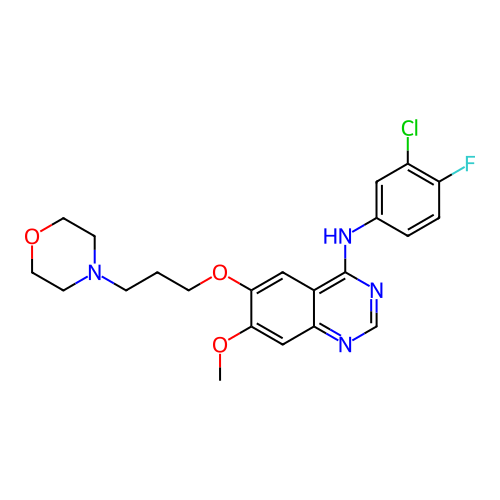

In [13]:
iressa_3d = Chem.MolFromSmiles('COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1 |(5.9801,-1.2502,0.9623;5.1811,-0.9472,-0.1795;3.8472,-1.21,-0.089;3.368,-2.4651,-0.476;2.0139,-2.7828,-0.4028;1.5715,-3.9953,-0.7797;0.2453,-4.2162,-0.6749;-0.6872,-3.3559,-0.235;-0.2104,-2.1519,0.1338;-1.1577,-1.2093,0.6057;-2.5153,-1.0034,0.3137;-3.0195,-1.3245,-0.9503;-4.3685,-1.1204,-1.2408;-5.2195,-0.5937,-0.2691;-6.5134,-0.4026,-0.5639;-4.7214,-0.2715,0.9935;-5.7668,0.3787,2.1969;-3.3725,-0.4761,1.2841;1.1345,-1.7975,0.0753;1.6085,-0.533,0.4663;2.9636,-0.2513,0.38;3.4187,0.9841,0.7617;3.4679,1.9878,-0.2429;3.2337,3.3454,0.4057;1.8687,3.4141,1.083;0.8065,3.1706,0.1093;-0.5076,3.1433,0.7665;-1.6,2.8996,-0.2708;-1.5666,3.9138,-1.2756;-0.3035,3.9266,-1.942;0.8208,4.194,-0.9454)|')
iressa_2d = Chem.MolFromSmiles(Chem.MolToSmiles(iressa_3d))
iressa_2d

In [14]:
IPythonConsole.drawMol3D(iressa_3d)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

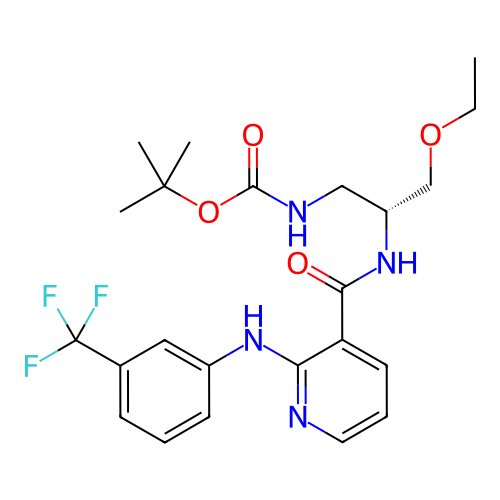

In [15]:
iressa_hit1 = Chem.MolFromSmiles("CCOC[C@@H](CNC(=O)OC(C)(C)C)NC(=O)c1cccnc1Nc1cccc(C(F)(F)F)c1 |(5.2741,-2.3996,-0.8944;5.7417,-1.0145,-0.5028;5.7156,-0.7252,0.7858;4.7152,-0.7582,1.6345;3.5244,0.1243,1.3442;4.027,1.5454,1.4245;3.0384,2.56,1.1822;2.3079,2.773,0.0154;2.4268,2.0869,-1.0113;1.382,3.8138,-0.0236;0.6264,4.0531,-1.1949;-0.2309,2.9123,-1.6274;1.5311,4.5679,-2.2915;-0.3281,5.2054,-0.8669;2.8409,-0.1956,0.1318;1.563,-0.7526,0.2479;0.6722,-0.0039,0.793;1.0982,-2.0545,-0.1638;1.8136,-3.0398,-0.7714;1.2457,-4.257,-1.1411;-0.0839,-4.4966,-0.8956;-0.7923,-3.5396,-0.3006;-0.2596,-2.3361,0.0748;-1.1303,-1.459,0.7324;-2.4765,-1.2025,0.3454;-2.8742,-1.257,-0.9822;-4.1945,-1.0121,-1.3631;-5.1472,-0.7065,-0.4077;-4.74,-0.6522,0.9358;-5.7585,-0.3317,2.0008;-5.3231,-0.9085,3.1973;-6.9174,-0.9833,1.6469;-5.8993,1.0072,2.221;-3.4272,-0.8965,1.2988),wD:4.4|")
iressa_hit1_2d = Chem.MolFromSmiles(Chem.MolToSmiles(iressa_hit1))
iressa_hit1_2d

In [16]:
IPythonConsole.drawMols3D([iressa_3d, iressa_hit1])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

The similarity scores in this example are

- Combined Similarity : 0.520
- Shape Score : 0.721
- Color Score : 0.320

The Shape Score is the shape Tanimoto (volume in common divided by the volume of the two molecules combined), the Color Score is the equivalent for pharmacophore features represented by Gaussian functions, with the overlap for matching feature types only, and the Combined Similarity is the mean of the two.

## Shape Searching in Fragment-Based Lead Discovery

A significant obstacle in [FBLD](https://en.wikipedia.org/wiki/Fragment-based_lead_discovery) is finding ways of linking 2 fragments such that their poses in the active site are largely maintained leading to a strongly active combined molecule.  The synthon space searching lends itself readily to searches of the disconnected fragments to find single molecules of similar shape and pharmacophore features that can be directly purchased for testing.  Adding an excluded volume gives a useful additional constraint to the hits.

The [OpenBind initiative](https://openbind.uk) have a number of FBLD projects running against anitviral targets.  One such is [RdRp](https://en.wikipedia.org/wiki/RNA-dependent_RNA_polymerase).  The structures of their screened fragments are available for [viewing](https://fragalysis.diamond.ac.uk/viewer/react/preview/target/Flavi_NS5_RdRp/tas/lb32633-1) and download.

Some initial testing of the synthon space shape searching has been carried using pairs of fragments downloaded from the site above using the FreedomSpace 5.0 library.

### Database Creation

The FreedomSpace 5.0 library comprises some 380,000 synthons which can be combined into 296 billion compounds.  The shape database was prepared as described above, using only synthons of 50 heavy atoms and fewer, with the RDKit conformer generator and a maximum of 100 conformations per synthon.

### Test 1

Two fragments (5f3t and z0103a) were selected by eye as being a few Ångstrom apart and relatively small. The excluded volume was created by selecting all atoms in the protein structure that were within 4Å of an atom in either fragment.  It is shown in red below.

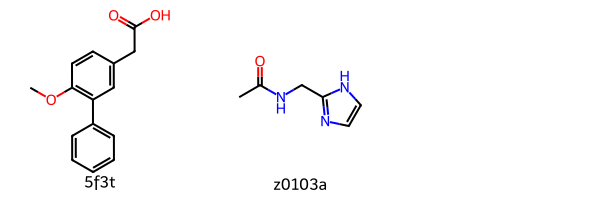

In [17]:
frags_2d = [Chem.MolFromSmiles("OC(=O)Cc1ccc(OC)c(c1)c2ccccc2"), Chem.MolFromSmiles("CC(=O)NCc1[nH]ccn1")]
Draw.MolsToGridImage(frags_2d, legends=["5f3t", "z0103a"])

In [18]:
combined_query = Chem.MolFromSmiles("CC(=O)NCc1ncc[nH]1.COc1ccc(CC(=O)O)cc1-c1ccccc1 |(-11.629,-40.624,-21.225;-12.944,-41.022,-21.833;-13.266,-42.197,-21.974;-13.726,-40.034,-22.248;-13.348,-39.222,-23.382;-12.966,-37.907,-22.925;-11.741,-37.458,-22.879;-11.837,-36.211,-22.299;-13.101,-35.942,-22.018;-13.818,-37.035,-22.421;-14.536,-43.268,-23.743;-15.603,-43.844,-22.984;-15.548,-43.934,-21.607;-14.598,-43.217,-20.856;-14.567,-43.341,-19.464;-15.475,-44.155,-18.78;-15.354,-44.279,-17.272;-16.437,-43.527,-16.546;-16.907,-44.019,-15.496;-16.811,-42.426,-17.01;-16.433,-44.903,-19.485;-16.52,-44.814,-20.886;-17.518,-45.619,-21.659;-18.218,-45.069,-22.741;-19.095,-45.863,-23.488;-19.325,-47.189,-23.134;-18.64,-47.738,-22.048;-17.727,-46.964,-21.326)|")
exc_vol = Chem.MolFromSmiles("C.C=O.CC.CC(C)CCN.CCNC.CCSC.CNC(=O)CCO.CSC.C[C@@H](CN)NC(=O)CCc1c[nH]cn1.C[C@@H](O)CCN.N.N=CN.NCCC(=O)O.NCCO.N[C@@H](CS)C(=O)NCCO.O.cc.ccO.cccc.cnc[nH] |(-13.803,-42.848,-27.927;-8.078,-33.418,-20.925;-9.135,-34.01,-21.221;-17.719,-37.014,-24.861;-16.473,-37.057,-24.003;-14.366,-46.23,-25.785;-15.717,-46.983,-25.843;-16.048,-47.691,-24.537;-16.857,-46.062,-26.283;-16.733,-45.463,-27.693;-17.938,-44.705,-28.035;-17.269,-47.475,-12.988;-17.349,-46.269,-12.057;-16.084,-45.53,-11.991;-15.678,-44.821,-10.942;-18.362,-51.665,-24.42;-19.442,-50.636,-24.833;-19.116,-50.022,-26.49;-20.703,-49.407,-26.934;-11.379,-32.274,-24.867;-11.736,-33.139,-25.988;-11.395,-34.417,-26.029;-10.751,-34.977,-25.135;-11.757,-35.163,-27.306;-12.177,-36.598,-26.992;-13.424,-36.621,-26.327;-21.05,-50.368,-20.427;-20.531,-49.052,-19.311;-19.541,-50.007,-18.118;-21.623,-43.468,-22.372;-21.475,-43.382,-23.885;-22.824,-43.058,-24.534;-23.37,-44.015,-25.3;-20.481,-42.369,-24.237;-19.733,-42.436,-25.343;-19.823,-43.361,-26.148;-18.744,-41.296,-25.597;-17.287,-41.787,-25.602;-16.301,-40.687,-25.837;-15.344,-40.185,-25.019;-14.737,-39.16,-25.705;-15.344,-39.06,-26.883;-16.291,-39.971,-27.017;-20.808,-44.567,-19.157;-20.018,-44.069,-17.947;-19.082,-43.079,-18.363;-20.927,-43.516,-16.807;-21.578,-42.184,-17.21;-20.832,-41.089,-17.046;-9.327,-32.581,-23.601;-11.038,-46.06,-16.658;-11.697,-46.806,-17.529;-12.817,-46.344,-18.064;-7.94,-34.875,-24.335;-7.405,-36.116,-24.908;-8.4,-37.273,-24.778;-8.487,-37.952,-23.44;-9.492,-37.73,-22.727;-7.674,-38.852,-23.189;-19.674,-40.289,-19.274;-18.858,-40.075,-20.48;-18.086,-41.342,-20.849;-17.373,-41.171,-22.064;-9.026,-41.538,-24.393;-10.287,-41.511,-23.654;-11.479,-41.446,-24.609;-11.468,-40.004,-25.715;-10.396,-42.677,-22.637;-11.401,-43.389,-22.592;-9.3,-42.9,-21.874;-9.169,-43.923,-20.818;-10.289,-43.778,-19.781;-10.461,-42.432,-19.373;-20.651,-45.882,-15.168;-15.605,-33.196,-24.359;-15.134,-34.088,-25.322;-16.679,-51.296,-21.019;-15.582,-50.638,-21.554;-15.523,-49.281,-21.461;-23.779,-49.454,-23.134;-22.917,-48.434,-23.499;-22.66,-47.356,-22.635;-23.249,-47.268,-21.397;-11.54,-47.221,-23.259;-12.163,-46.149,-22.634;-13.2,-46.661,-21.996;-13.273,-47.979,-22.169),wD:44.35,64.50,wU:30.21|", sanitize=False)
IPythonConsole.drawMols3D([combined_query, exc_vol])

[17:42:16] non-ring atom 74 marked aromatic


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

They were used to search the FreedomSpace 5.0 library with a Tversky similarity cutoff of 0.7 and the top million possible hits built and checked for similarity to the query.  The search was run on the IRIS cluster at the [Diamond Light Source](https://www.diamond.ac.uk/Home.html).  Stage one, identifying possible hits, was run on a 200 CPU machine and took some 8 CPU days (roughly an hour of actual time) and the second stage was run as 200 single CPU jobs each processing 5000 possible hits which took roughly 3 further hours (a total of about 15 CPU days for the full search).  The best hit, shown below (in blue in the 3D display), had a Tversky similarity of 0.79 and there were 2852 in total.

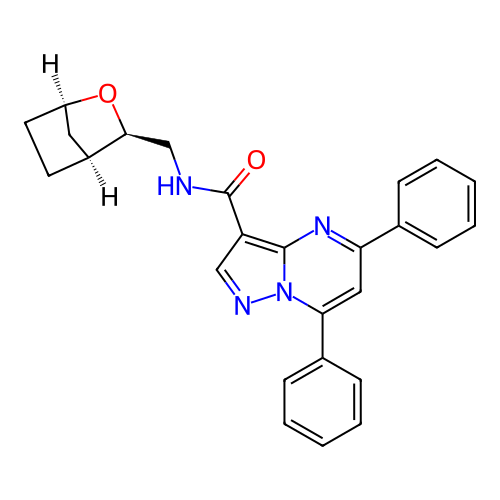

In [19]:
hit0 = Chem.MolFromSmiles("O=C(NC[C@@H]1O[C@@H]2CC[C@H]1C2)c1cnn2c(-c3ccccc3)cc(-c3ccccc3)nc12 |(-12.3794,-41.9504,-20.918;-13.1794,-41.6975,-21.8533;-13.1539,-40.4582,-22.561;-12.1732,-39.4818,-22.1691;-12.2942,-38.2614,-23.0128;-11.3779,-37.2651,-22.6782;-12.123,-36.1386,-22.3551;-12.9653,-36.4536,-21.1504;-14.0985,-37.3329,-21.6666;-13.6322,-37.6234,-23.0736;-13.1924,-36.1975,-23.4569;-14.1768,-42.6744,-22.2546;-14.5278,-43.1485,-23.4917;-15.5321,-44.0304,-23.3197;-15.813,-44.118,-22.0355;-16.7249,-44.8471,-21.3565;-17.6648,-45.7511,-21.9995;-17.892,-46.969,-21.3808;-18.7731,-47.9126,-21.9152;-19.4451,-47.6255,-23.1051;-19.2115,-46.3988,-23.7218;-18.327,-45.4694,-23.1703;-16.8105,-44.7445,-19.9613;-15.9786,-43.9116,-19.255;-16.0093,-43.7911,-17.7966;-16.9181,-44.5027,-17.0214;-16.9031,-44.3717,-15.6385;-15.9623,-43.5164,-15.0459;-15.053,-42.8031,-15.7921;-15.0954,-42.9566,-17.1641;-15.0856,-43.2023,-19.9732;-15.0112,-43.3066,-21.3249),wU:4.3,6.6,9.8|")
hit0_2d = Chem.MolFromSmiles(Chem.MolToSmiles(hit0))
hit0_2d

In [20]:
IPythonConsole.drawMols3D([combined_query, exc_vol, hit0])

[17:42:16] non-ring atom 74 marked aromatic


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Another hit, with a different chemistry in the middle, was 1648 in the list, with a Tversky score of 0.70 and is shown below.

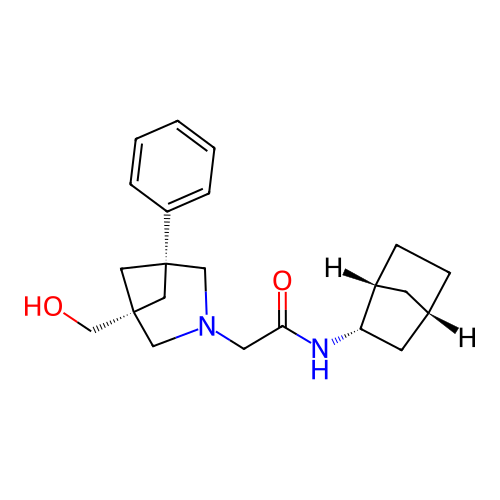

In [21]:
hit1648 = Chem.MolFromSmiles("O=C(CN1C[C@]2(CO)C[C@](c3ccccc3)(C1)C2)N[C@H]1C[C@H]2CC[C@@H]1C2 |(-12.4609,-41.246,-21.317;-13.5299,-40.908,-21.9189;-14.6849,-41.8298,-22.0109;-14.4906,-43.0889,-21.3742;-14.413,-43.0618,-19.9504;-15.5104,-43.8711,-19.2968;-15.546,-43.7444,-17.808;-16.5883,-44.5212,-17.256;-16.8343,-43.7152,-20.0176;-16.2912,-44.7253,-21.0029;-17.267,-45.6028,-21.6345;-18.4385,-45.0563,-22.1169;-19.4198,-45.8378,-22.7348;-19.2145,-47.2101,-22.8708;-18.0322,-47.7828,-22.3879;-17.1057,-46.9613,-21.7898;-15.2633,-44.1428,-21.9437;-15.5046,-45.2917,-19.8271;-13.6751,-39.628,-22.5366;-12.6571,-38.6374,-22.5383;-12.1429,-38.1225,-23.8146;-11.8261,-36.6567,-23.5282;-13.1187,-35.9078,-23.5726;-13.8444,-36.4216,-22.3368;-12.9055,-37.4076,-21.701;-11.5792,-36.7069,-22.0156),wD:9.9,19.21,24.26,wU:5.5,21.23|")
hit1648_2d = Chem.MolFromSmiles(Chem.MolToSmiles(hit1648))
hit1648_2d

In [22]:
IPythonConsole.drawMols3D([combined_query, exc_vol, hit1648])

[17:42:16] non-ring atom 74 marked aromatic


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Two other pairs of fragments were selected using similarly vague criteria and used to search FreedomSpace 5.0.  Despite being the results of preliminary benchmarking and testing investigations, the hits were sufficiently interesting to the OpenBind programme that some were selected for purchase.  Results of testing these in the project assays will be reported elsewhere.

## MedChemica's Thoughts

MedChemica (part of the [OpenBind Consortium](https://openbind.uk) project) have [some thoughts about the work](https://www.medchemica.com/consulting/?utm_source=blog+post&utm_medium=website+&utm_campaign=RDKit-shapesynthonsearch-Aug2026).

## Acknowledgements

The extension of Synthon Space searching to include shape similarity was funded by the [OpenBind Consortium](https://openbind.uk).  Thanks are due to Ed Griffen (MedChemica Limited) and Fergus Imrie (University of Oxford) for their help obtaining the funding and for valuable discussions during development, and particularly the suggestion of adding excluded volumes to the search scoring. The staff at the Diamond Cluster were very helpful with getting me up and running on their IRIS cluster.  Lauren Reid (MedChemica Limited) gave great assistance with the RdRp tests.

Several members of the RDKit community, notably Greg Landrum (ETH Zurich), Dan Nealschneider (Schrödinger) and Brian Kelley (Glysade), were very helpful during implementation, testing and review of the code. 